In [29]:
%load_ext autoreload
%autoreload 2
import numpy as np
import matplotlib.pyplot as plt
from coffea import util
from coffea.processor import accumulate
import os
import re
import pandas as pd
import hist
import matplotlib as mpl
import mplhep
import sys
import hist
import hist.intervals

sys.path.append("../analysisTools/")
import plotTools as ptools
import utils

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [36]:
#coffea output file
f_sig = "../coffea/new_signal_2022/match_new.coffea"
#Nested Dictionary:
sig_histo = util.load(f_sig) [0]
sig_histo.keys()

dict_keys(['gen_ele_pt', 'gen_ele_eta', 'gen_ele_phi', 'gen_ele_vxy1', 'gen_ele_vxy10', 'gen_ele_vxy100', 'match_ele_gen_pt', 'match_ele_gen_vxy1', 'match_ele_gen_vxy10', 'match_ele_gen_vxy100', 'PFMET', 'PFMET_vs_genMET', 'cutDesc', 'cutflow', 'cutflow_cts', 'cutflow_nevts', 'cutflow_vtx_matched'])

Saved: ./plots/signal_2018/gen_ele_vxy10_m110.png
count_den: [20. 10. 10.  4.  6.  8.  2.  2.  2.  2.  6.  8. 16.  6.  6.  0.  2.  4.
  6.  6.  2.  6.  4.  4. 10.  4.  0.  4.  4.  6.  2.  2.  2.  4.  6.  8.
  4.  2.  6.  2.  2.  0.  4.  4.  0.  0.  2.  4.  0.  4.  0.  0.  0.  2.
  4.  8.  4.  2.  4.  2.  0.  0.  0.  2.  0.  2.  0.  0.  2.  0.  0.  4.
  2.  4.  0.  0.  2.  0.  0.  4.  0.  4.  4.  0.  0.  2.  0.  2.  0.  0.
  0.  2.  2.  2.  2.  0.  0.  0.  0.  2.]
Saved: ./plots/signal_2018/match_ele_gen_vxy10_m110.png
count_num: [6. 3. 3. 2. 1. 4. 0. 0. 0. 1. 4. 1. 5. 1. 2. 0. 0. 2. 1. 2. 0. 0. 0. 0.
 2. 0. 0. 3. 0. 1. 0. 1. 0. 0. 0. 1. 2. 0. 0. 1. 0. 0. 0. 1. 0. 0. 0. 0.
 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0.]


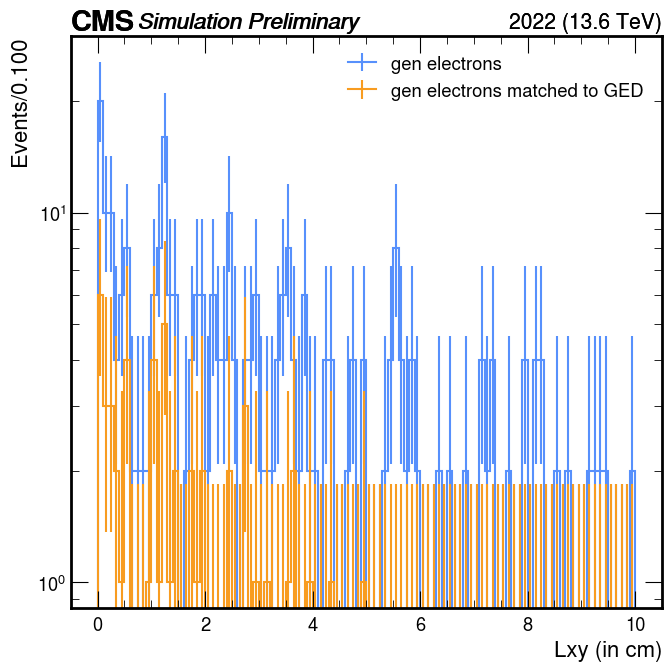

In [51]:
#FOR GED electrons


fig, ax = plt.subplots(figsize=(7,7))

m1=100
delta = 0.1
ctau = 100

# Plot settings
plot_dict = {
    'variable': 'gen_ele_vxy10',
    'cut': 'cut1',
    'year': 2022
}

style_dict = {
    'fig': fig,
    'ax': ax,
    'rebin': None,
    'xlim': None,     # if None, the default will show up; otherwise give as a list, i.e. [0, 10]
    'doLogy': True, 
    'doLogx': False,
    'doDensity': False,
    'doYerr': True, 
    'xlabel': "Lxy (in cm)",   # if None, the default will show up; otherwise give as a string, i.e. 'Electron dxy'
    'ylabel': None,   # if None, the default will show up; otherwise give as a string, i.e. 'Efficiency'
    'label': "gen electrons",    # if None, the default will show up; otherwise give as a string, i.e. 'Highest ctau signal samples'
    'flow': None,     # overflow
    'doSave': True,
    'outDir': './plots/signal_2018',
    'outName': f'gen_ele_vxy10_m110.png'
}
#####
count_den, edges_den = ptools.plot_signal_1D_lxy(sig_histo, m1, delta, ctau, plot_dict, style_dict, match_type='R', passID=1)

print ("count_den:", count_den)
count_den = np.array(count_den)

indices = np.where(count_den == 0)
deno = count_den[count_den != 0]  #IMP


#####
den_edges = np.array(edges_den)
bins_deno = np.delete(den_edges, indices)
###########################################################



m1=100
delta = 0.1
ctau = 100
#fig, ax = plt.subplots(figsize=(7,7))

plot_dict = {'variable': 'match_ele_gen_vxy10', 'cut': 'cut1', 'year': 2022}

style_dict = {
    'fig': fig,
    'ax': ax,
    'rebin': None,
    'xlim': None,     # if None, the default will show up; otherwise give as a list, i.e. [0, 10]
    'doLogy': True, 
    'doLogx': False,
    'doDensity': False,
    'doYerr': True, 
    #'xlabel': "pT of gen electrons(matched to 'R')",  
    'xlabel': "Lxy (in cm)",              # if None, the default will show up; otherwise give as a string, i.e. 'Electron dxy'
    'ylabel': None,   # if None, the default will show up; otherwise give as a string, i.e. 'Efficiency'
    'label': "gen electrons matched to GED",    # if None, the default will show up; otherwise give as a string, i.e. 'Highest ctau signal samples'
    'flow': None,     # overflow
    'doSave': True,
    'outDir': './plots/signal_2018',
    'outName': f'match_ele_gen_vxy10_m110.png'
}
count_num, edges_num = ptools.plot_signal_1D_lxy(sig_histo, m1, delta, ctau, plot_dict, style_dict, match_type='R', passID=1)

print ("count_num:", count_num)
#########
count_num = np.array(count_num)

num = np.delete(count_num, indices)

#########
edges_num = np.array(edges_num)
bins_num = np.delete(edges_num, indices)


#Calculation for the efficiency plot
bins_x = (bins_num[:-1] + bins_num[1:])*(0.5)
#print ("bins_x:",bins_x)

xerr = (bins_num[1:] - bins_num[:-1])*(0.5)
#print ("xerr:",xerr)


Saved: ./plots/signal_2022/gen_ele_pT_Lmatch.png
count_den_L: [ 0.  0.  0.  0.  0.  2.  2.  4.  0.  0.  2.  0.  0.  2.  2.  2.  0.  2.
  2.  2.  4.  2.  0.  4.  4.  4.  4. 10.  2.  8.  6.  6.  2.  6.  8. 12.
  4.  2.  6. 12. 14.  8. 18. 24.  6. 10. 12.  6. 10.  6. 14.  8. 10.  6.
  6. 10.  2.  6. 14. 10.  4. 14.  6.  8. 12. 18.  8. 10.  6.  6.  4.  8.
 10. 12.  6.  6.  2.  8.  6.  6.  8.  8.  6. 10.  2.  4.  4.  8.  4.  4.
  4.  6.  4.  4.  8.  0.  6.  2.  2.  2.  4.  0.  0.  6.  6.  2.  2.  4.
  6.  8. 10. 12. 10.  2. 10.  4.  2. 10. 16.  6.  6.  6.  8.  8.  6.  4.
 10.  6.  2.  4.  6.  4.  4.  4.  8.  4.  6.  6.  8.  4.  4.  6. 16.  6.
 12.  2. 10.  8.  2.  6.  4.  2.  6. 12.  6.  6. 12.  6.  6.  4. 12.  4.
  2.  6. 16.  4.  6.  0. 10.  2.  4.  6.  8.  2. 12.  8.  2.  6.  2. 10.
  2.  6.  6.  6.  6.  6. 10.  6.  8.  8.  6.  8.  6.  6.  4.  4.  6.  0.
  8.  2.  2.  4.  0.  4.  0.  6.  0.  6.  6.  8. 10.  2.  4. 10.  6.  2.
  2.  4.  4. 14.  2.  2.  4.  0.  2.  6.  6.  0.  4.  2.  0.  

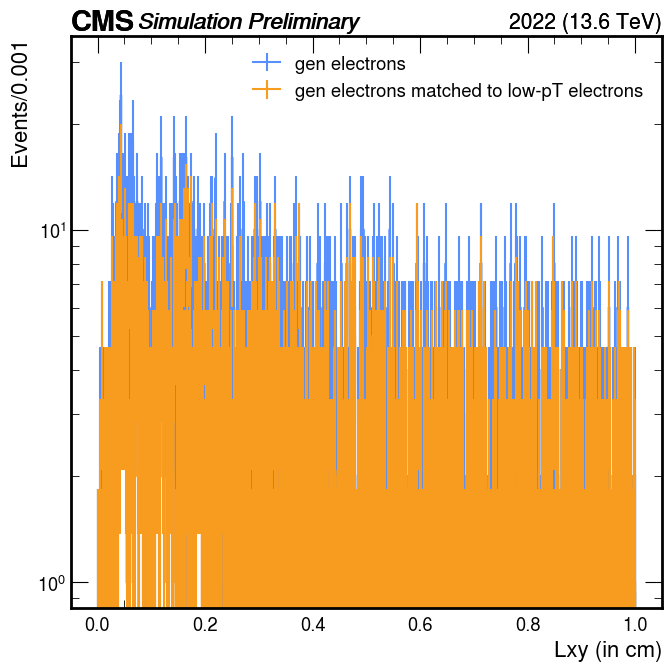

In [42]:
#For low-pT electrons

fig, ax = plt.subplots(figsize=(7,7))

m1=100
delta = 0.1
ctau = 10

# Plot settings
plot_dict = {
    'variable': 'gen_ele_vxy1',
    'cut': 'cut1',
    'year': 2022
}

style_dict = {
    'fig': fig,
    'ax': ax,
    'rebin': None,
    'xlim': None,     # if None, the default will show up; otherwise give as a list, i.e. [0, 10]
    'doLogy': True, 
    'doLogx': False,
    'doDensity': False,
    'doYerr': True, 
    'xlabel': "gen_ele_pt",   # if None, the default will show up; otherwise give as a string, i.e. 'Electron dxy'
    'ylabel': None,   # if None, the default will show up; otherwise give as a string, i.e. 'Efficiency'
    'label': "gen electrons",    # if None, the default will show up; otherwise give as a string, i.e. 'Highest ctau signal samples'
    'flow': None,     # overflow
    'doSave': True,
    'outDir': './plots/signal_2022',
    'outName': f'gen_ele_pT_Lmatch.png'
}
#####
count_den_L, edges_den_L = ptools.plot_signal_1D_lxy(sig_histo, m1, delta, ctau, plot_dict, style_dict, match_type='L', passID=1)
count_den_L = np.array(count_den_L)
#print ("len(edges_den):", len(edges_den))
print ("count_den_L:", count_den_L)
#print ("len(count_den):", len(count_den))
indices_L = np.where(count_den_L == 0)
deno_L = count_den_L[count_den_L != 0]  #IMP


#####
den_edges_L = np.array(edges_den_L)
bins_deno_L = np.delete(den_edges_L, indices_L)
###########################################################



m1=100
delta = 0.1
ctau = 10
#fig, ax = plt.subplots(figsize=(7,7))

plot_dict = {'variable': 'match_ele_gen_vxy1', 'cut': 'cut1', 'year': 2022}

style_dict = {
    'fig': fig,
    'ax': ax,
    'rebin': None,
    'xlim': None,     # if None, the default will show up; otherwise give as a list, i.e. [0, 10]
    'doLogy': True, 
    'doLogx': False,
    'doDensity': False,
    'doYerr': True, 
    #'xlabel': "pT of gen electrons(matched to 'R')",  
    'xlabel': "Lxy (in cm)",              # if None, the default will show up; otherwise give as a string, i.e. 'Electron dxy'
    'ylabel': None,   # if None, the default will show up; otherwise give as a string, i.e. 'Efficiency'
    'label': "gen electrons matched to low-pT electrons",    # if None, the default will show up; otherwise give as a string, i.e. 'Highest ctau signal samples'
    'flow': None,     # overflow
    'doSave': True,
    'outDir': './plots/signal_2022',
    'outName': f'match_ele_gen_pt_L.png'
}
count_num_L, edges_num_L = ptools.plot_signal_1D_lxy(sig_histo, m1, delta, ctau, plot_dict, style_dict, match_type='L', passID=1)

#########
count_num_L = np.array(count_num_L)
#print ("edges_num_L:", edges_num_L)
print ("count_num_L:", count_num_L)
num_L = np.delete(count_num_L, indices_L)

#########
edges_num_L = np.array(edges_num_L)
bins_num_L = np.delete(edges_num_L, indices_L)


#Calculation for the efficiency plot
bins_x_L = (bins_num_L[:-1] + bins_num_L[1:])*(0.5)


xerr_L = (bins_num_L[1:] - bins_num_L[:-1])*(0.5)







In [43]:
def eff_determine_unc(n, d):
    eff = np.divide(n, d)
    unc = hist.intervals.ratio_uncertainty(n, d, 'efficiency')
    return eff, unc

efficiency_R, unc_eff_R = eff_determine_unc(num, deno)
yerr_R = [unc_eff_R[0], unc_eff_R[1]]

efficiency_L, unc_eff_L = eff_determine_unc(num_L, deno_L)
yerr_L= [unc_eff_L[0], unc_eff_L[1]]

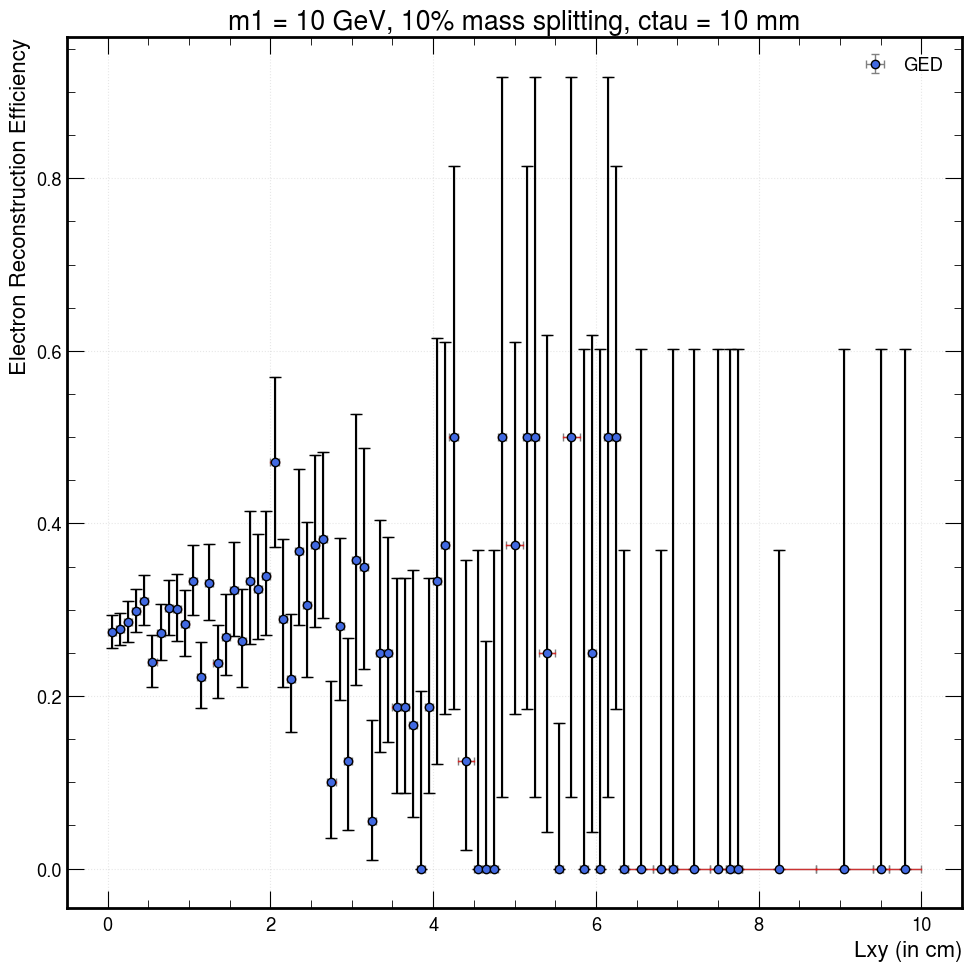

In [44]:
#GED
plt.errorbar(
    bins_x, efficiency_R,
    yerr=yerr_R, xerr=xerr,
    fmt='o', markersize=6, markerfacecolor='royalblue', markeredgecolor='black',
    ecolor='gray', elinewidth=1, capsize=3,
    label='GED'
)

# Draw y errors thicker and darker
plt.errorbar(
    bins_x, efficiency_R,
    yerr=yerr_R,
    fmt='none', ecolor='black', elinewidth=1.5, capsize=4
)

# Draw x errors thinner and lighter
plt.errorbar(
    bins_x, efficiency_R,
    xerr=xerr,
    fmt='none', ecolor='red', elinewidth=1, capsize=1, alpha=0.6
)


# # #Low pT
# plt.errorbar(
#     bins_x_L, efficiency_L,
#     yerr=yerr_L, xerr=xerr_L,
#     fmt='s', markersize=5, markerfacecolor='darkorange', markeredgecolor='black',
#     ecolor='orange', elinewidth=1, capsize=3,
#     label='Low-pT'
# )

# # Low-pT y errors thicker
# plt.errorbar(
#     bins_x_L, efficiency_L,
#     yerr=yerr_L,
#     fmt='none', ecolor='orange', elinewidth=1.5, capsize=4
# )

# # Low-pT x errors thinner
# plt.errorbar(
#     bins_x_L, efficiency_L,
#     xerr=xerr_L,
#     fmt='none', ecolor='red', elinewidth=1, capsize=1, alpha=0.6
# )

#plt.plot(bins_x_L, efficiency_L, color='darkorange', linestyle='--', linewidth=1.5)
plt.xlabel("Lxy (in cm)")
plt.ylabel("Electron Reconstruction Efficiency")
plt.title("m1 = 10 GeV, 10% mass splitting, ctau = 10 mm")
plt.legend(loc='upper right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("Electron_Reconstruction_Eff_GEDlowpT.png", dpi=300)
